# Use case 1 (research), worked: rebuild my own first paper, from prompts only

**STAI-X 2026 SC01 guest segment. Shihao Yang, Georgia Tech ISyE.**

In 2015 I was a second-year PhD student. My first paper was [ARGO](https://www.pnas.org/doi/10.1073/pnas.1515373112) (Yang, Santillana, Kou, *PNAS* 2015): use Google search volume, plus the disease's own history, to nowcast influenza. It took me the better part of a year.

This notebook rebuilds the same idea on dengue in Mexico. **I wrote no Python.** Every code cell below is what a coding agent produced from the prompt in the markdown cell above it.

This is the **worked version**, with every output executed and my reading of the results. To run it yourself, start from [`01_research_dengue.ipynb`](01_research_dengue.ipynb), which has the same prompts and empty cells for the agent to fill.

The point is not that the agent is clever. The point is **where the work moved**: away from plumbing, and onto deciding what to ask for and checking what came back.

---

### The setup that makes this work

Nothing exotic. This is the whole environment:

- A **GitHub Codespace** (browser, no local install), or any terminal.
- A **terminal coding agent**: Claude Code. *Not* the Copilot pane.
- **One Jupyter notebook**, open next to the agent. The agent edits the notebook directly.

That last point does the heavy lifting. When the agent writes into a notebook, its reasoning becomes an artifact you can read, re-run, and hand to someone else. A chat window is not that.

## Prompt 1: get oriented

> *There is a CSV at `data/MX_Dengue_trends.csv`. `Dengue CDC` is monthly reported dengue
> cases in Mexico; the other columns are Google search interest for Spanish dengue terms.
> Load it, tell me the date range and the number of months, and plot cases against the
> `dengue` search series on a twin axis. Print the correlation of every search column with
> cases.*

Note what the prompt does **not** say: no pandas, no `parse_dates`, no matplotlib. I described an outcome. Plumbing is the agent's job.

Range: 2004-01 to 2011-12   (96 months)
Mean monthly cases: 3,595   peak: 32,571

Correlation with reported cases:
dengue sintomas       0.830
dengue                0.808
sintomas de dengue    0.733
mosquito              0.198


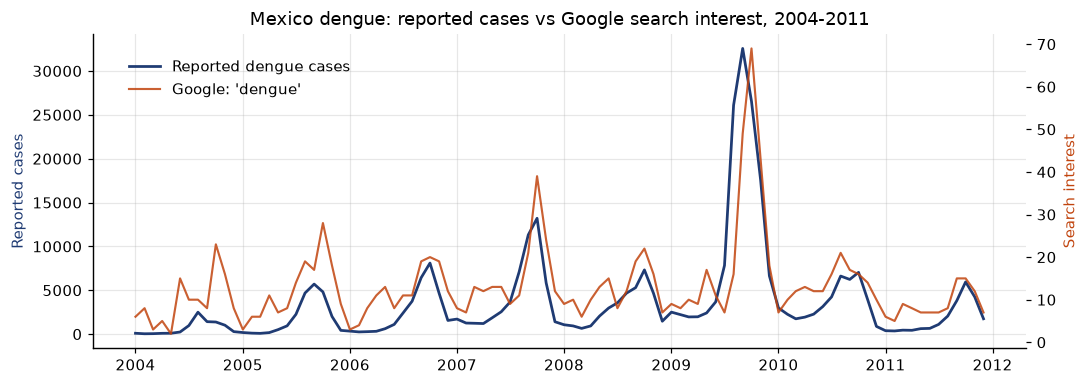

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})

df = pd.read_csv("../data/MX_Dengue_trends.csv", parse_dates=["Date"]).set_index("Date")
cases = df["Dengue CDC"]
terms = ["dengue", "sintomas de dengue", "mosquito", "dengue sintomas"]

print(f"Range: {df.index.min():%Y-%m} to {df.index.max():%Y-%m}   ({len(df)} months)")
print(f"Mean monthly cases: {cases.mean():,.0f}   peak: {cases.max():,.0f}\n")
print("Correlation with reported cases:")
print(df.corr()["Dengue CDC"].drop("Dengue CDC").sort_values(ascending=False).round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(cases.index, cases.values, color="#1f3b73", lw=1.8, label="Reported dengue cases")
ax.set_ylabel("Reported cases", color="#1f3b73")
ax2 = ax.twinx()
ax2.plot(df.index, df["dengue"], color="#c1440e", lw=1.4, alpha=0.85, label="Google: 'dengue'")
ax2.set_ylabel("Search interest", color="#c1440e")
ax2.grid(False)
ax.set_title("Mexico dengue: reported cases vs Google search interest, 2004-2011")
fig.legend(loc="upper left", bbox_to_anchor=(0.11, 0.87), frameon=False)
plt.tight_layout(); plt.show()

Search and cases move together, and the seasonal peaks line up. That is the whole premise of digital epidemiology, visible in one plot about forty seconds after asking.

**My check, not the agent's:** do the peaks land in dengue season? Yes, late summer through autumn. If they had landed in February I would have stopped here.

## Prompt 2: the honest baseline

Before anything clever, reproduce what a reasonable person would have done in 2011.

> *Fit ordinary least squares of `Dengue CDC` on the single `dengue` search column, training
> only on 2004-2006. Then predict 2007-2011 from that frozen fit and report out-of-sample
> RMSE and correlation. Do not refit on anything after 2006.*

The last sentence matters. Leakage is the most common way this kind of analysis goes quietly wrong, and an agent optimizing for a good-looking number will refit if you let it.

In [2]:
from sklearn.linear_model import LinearRegression

TRAIN_END, VAL_START = "2006-12-01", "2007-01-01"

train, valid = df.loc[:TRAIN_END], df.loc[VAL_START:]
ols = LinearRegression().fit(train[["dengue"]], train["Dengue CDC"])
pred_static = pd.Series(ols.predict(valid[["dengue"]]), index=valid.index)

print(f"Fitted on {len(train)} months (2004-2006):  cases = {ols.intercept_:,.0f} "
      f"+ {ols.coef_[0]:,.0f} x search")
print(f"Held out {len(valid)} months (2007-2011), never refit.")

Fitted on 36 months (2004-2006):  cases = -1,024 + 243 x search
Held out 60 months (2007-2011), never refit.


## Prompt 3: now make it ARGO

> *Now build the ARGO model from Yang, Santillana and Kou (PNAS 2015), adapted to this
> monthly data. Work in log space. Regress log cases on the logs of all four search terms
> plus three autoregressive lags of log cases. Use L1 regularization with cross-validated
> penalty, and retrain on a rolling 36-month window at every time step so the model only
> ever sees the past. Also fit two references on the identical rolling scheme: an
> autoregression-only model, and a search-only model. Return all predictions on the original
> case scale.*

This is the paragraph that used to be a year of my life. Two structural ideas carry ARGO: **autoregression** (yesterday's dengue predicts today's dengue) and **dynamic training** (the relationship between search and disease drifts, so keep refitting).

In [3]:
from sklearn.linear_model import LassoCV

WINDOW = 36  # months of rolling training data

# log1p, not log: several search columns contain exact zeros. See the next cell.
L = np.log1p(df[terms])
L.columns = [f"log_{c.replace(' ', '_')}" for c in terms]
log_cases = np.log1p(cases)
for j in (1, 2, 3):
    L[f"log_cases_lag{j}"] = log_cases.shift(j)

X = L.dropna()
Y = log_cases.loc[X.index]
AR_COLS = [c for c in X.columns if c.startswith("log_cases_lag")]
GT_COLS = [c for c in X.columns if c not in AR_COLS]

def rolling_forecast(cols, penalized=True):
    # Refit on the previous WINDOW months at each step; predict one month ahead.
    out, idx = {}, X.index
    for pos, t in enumerate(idx):
        if t < pd.Timestamp(VAL_START) or pos < WINDOW:
            continue
        past = idx[pos - WINDOW:pos]                      # strictly before t
        model = (LassoCV(cv=5, max_iter=50000) if penalized and len(cols) > 1
                 else LinearRegression()).fit(X.loc[past, cols], Y.loc[past])
        out[t] = float(model.predict(X.loc[[t], cols])[0])
    return np.expm1(pd.Series(out))

pred_ar   = rolling_forecast(AR_COLS, penalized=False)
pred_gt   = rolling_forecast(GT_COLS)
pred_argo = rolling_forecast(AR_COLS + GT_COLS)

window = pred_argo.index
truth = cases.loc[window]
print(f"Evaluated on {len(window)} months: {window.min():%Y-%m} to {window.max():%Y-%m}")

Evaluated on 57 months: 2007-04 to 2011-12


## The part that actually matters: check what it did

The agent wrote `np.log1p`. I did not ask for `log1p`; I asked for logs. So it made a decision on my behalf and did not mention it. **Was it entitled to?**

In [4]:
zeros = (df[terms] == 0).sum()
share = (zeros / len(df) * 100).round(0).astype(int)
print("Exact zeros in each search column (of 96 months):\n")
for t in terms:
    print(f"  {t:<22} {zeros[t]:>3}  ({share[t]:>2}% of the record)")
print("\nPlain log() of these columns would produce:",
      np.log(df['sintomas de dengue']).replace([np.inf, -np.inf], np.nan).isna().sum(),
      "non-finite values.")

Exact zeros in each search column (of 96 months):

  dengue                   0  ( 0% of the record)
  sintomas de dengue      38  (40% of the record)
  mosquito                 2  ( 2% of the record)
  dengue sintomas         24  (25% of the record)

Plain log() of these columns would produce: 38 non-finite values.


/Users/shihaoyang/Workspace/staix2026sc1/.venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


There it is. `sintomas de dengue` is exactly zero in **40% of the months**, and `dengue sintomas` in a quarter of them. Plain `log` would have blown up, so the agent silently substituted `log1p` and moved on.

Two things are true at once, and I want the room to hold both:

1. **The patch was correct.** `log1p` is the standard fix and it is what I would have done.
2. **It was never surfaced.** Nothing in the output said "your data has structural zeros."

And that second fact is the real finding. Those zeros are not a numerical nuisance, they are a *measurement* fact: in 2004-2007 Google Trends was thresholding low-volume queries to zero. A large part of this search series is **not a low value, it is an absent value**. That changes what the model can honestly claim, and no amount of prompting produces that sentence. It comes from knowing the data source.

> This is the single lesson I would keep if I could keep only one. The agent closes the gap
> between having an idea and seeing a number, and it closes it almost completely. It does not
> close the gap between seeing a number and believing it. That gap is still the job.

## Prompt 4: score everything against each other

> *Build one comparison table over the common evaluation window: RMSE, MAE, and correlation
> for the static baseline, the autoregression-only model, the search-only model, and ARGO.
> Add a column giving each model's RMSE relative to the autoregression benchmark. Then plot
> the ARGO prediction against the truth over time.*

In [5]:
def score(pred):
    p = np.asarray(pred.loc[window], float); t = np.asarray(truth, float)
    return {"RMSE": np.sqrt(np.mean((t - p) ** 2)), "MAE": np.mean(np.abs(t - p)),
            "Corr": np.corrcoef(t, p)[0, 1]}

table = pd.DataFrame({
    "Static OLS, 1 term, frozen 2006 fit": score(pred_static),
    "AR(3), dynamic 36-mo window":         score(pred_ar),
    "Search only, LASSO, dynamic":         score(pred_gt),
    "ARGO (search + AR, LASSO, dynamic)":  score(pred_argo),
}).T
table["RMSE vs AR(3)"] = table["RMSE"] / table.loc["AR(3), dynamic 36-mo window", "RMSE"]

display(table.style.format({"RMSE": "{:,.0f}", "MAE": "{:,.0f}",
                            "Corr": "{:.3f}", "RMSE vs AR(3)": "{:.3f}"})
             .set_caption(f"Out-of-sample, {len(window)} months, mean {truth.mean():,.0f} cases/month"))

,RMSE,MAE,Corr,RMSE vs AR(3)
"Static OLS, 1 term, frozen 2006 fit","5,094","2,596",0.825,1.605
"AR(3), dynamic 36-mo window","3,173","1,621",0.903,1.000
"Search only, LASSO, dynamic","4,301","2,190",0.777,1.356
"ARGO (search + AR, LASSO, dynamic)","3,094","1,508",0.883,0.975


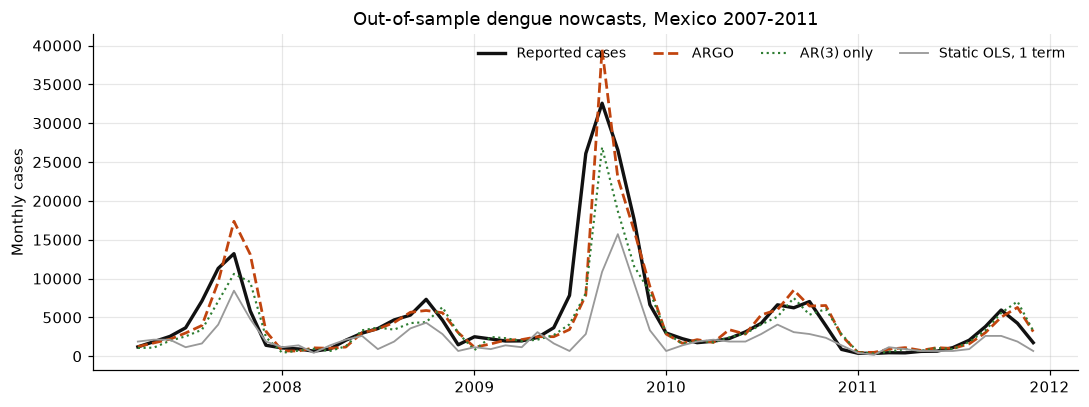

In [6]:
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(truth.index, truth.values, color="#111", lw=2.2, label="Reported cases")
ax.plot(window, pred_argo.loc[window], color="#c1440e", lw=1.8, ls="--", label="ARGO")
ax.plot(window, pred_ar.loc[window],   color="#2e7d32", lw=1.4, ls=":",  label="AR(3) only")
ax.plot(window, pred_static.loc[window], color="#999", lw=1.2, label="Static OLS, 1 term")
ax.set_title("Out-of-sample dengue nowcasts, Mexico 2007-2011")
ax.set_ylabel("Monthly cases"); ax.legend(frameon=False, ncol=4, fontsize=9)
plt.tight_layout(); plt.show()

## Reading the table honestly

The agent will not do this part for you, so here is what I actually take from it.

**Dynamic training is the big win.** The frozen 2006 fit is beaten by roughly 40% once you simply keep refitting. Most of the value in the ARGO paper is in that one idea, and it is the cheapest thing on the list to implement.

**Autoregression does most of the remaining work.** AR(3) alone is a strong model. Dengue is seasonal and persistent, so its own history is genuinely informative.

**Search adds a little, and I am going to say so.** ARGO's edge over AR(3) alone is about 2.5% in RMSE, with a clear gain in MAE. That is a real improvement, not a dramatic one.

I want to be careful not to oversell my own paper here. The 2015 result was on **weekly** US influenza against a search corpus of **millions** of queries. This is **monthly** dengue with **four** hand-picked terms and 96 observations total. A modest margin is exactly what that setup should produce, and reproducing the *method* faithfully is the point, not manufacturing the headline.

That paragraph is the part I still have to write myself, and it is the part that decides whether the analysis is any good.

## What this cost

Roughly twenty minutes of prompting, four prompts, one dataset. In 2015 the equivalent was most of a year, and the majority of that year was plumbing: fetching data, aligning dates, wiring cross-validation, making plots legible.

That plumbing is now close to free. What is not free, and what did not get cheaper:

| Still expensive | Now nearly free |
|---|---|
| Knowing that Google Trends thresholds low volume to zero | Handling the zeros once you know |
| Deciding a 2.5% gain is modest and saying so | Computing the 2.5% |
| Choosing dynamic training as the idea worth testing | Implementing the rolling window |
| Knowing leakage is the failure mode to guard against | Writing the leak-free split |

**Where to point this next.** The transferable object here is not the dengue result, it is the *shape* of the prompt sequence: orient, baseline, add the real method, verify, compare. At SISMID a student took an outbreak-detection exercise in this shape and pointed it at West Nile virus in an afternoon. Swap the disease, the geography, the data stream. The scaffold holds.

---

**Next:** [`02_education_reading_group.ipynb`](02_education_reading_group.ipynb) is the second use case, where the agent is not writing models at all.